In [93]:
from dataclasses import dataclass
import itertools

import numpy as np
import pandas as pd
from tqdm import tqdm_notebook as tqdm

import torch
from torch import nn
from torch.nn import functional as F

# Bandit Student-Faculty Setup

In [118]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers=2):
        super().__init__()
        self.input_layer = nn.Linear(input_size, hidden_size, bias=False)
        self.hidden_layers = nn.ModuleList(
            nn.Linear(hidden_size, hidden_size, bias=False) for _ in range(num_hidden_layers)
        )
        self.output_layer = nn.Linear(hidden_size, output_size, bias=False)

    def forward(self, x):
        x = self.input_layer(x)
        x = F.rms_norm(x, (x.shape[-1],))
        for layer in self.hidden_layers:
            x = layer(x)
            x = F.rms_norm(x, (x.shape[-1],))
        x = self.output_layer(x)
        return x

## Bandit Faculty Network (Ground joint policy)

In [119]:
@dataclass
class BanditFacultyConfig:
    dim_state: int
    num_actions: int
    num_teachers_total: int

    dim_observation: int
    observation_fn_layers: int
    observation_fn_dim: int

    seed_init: int

    num_teachers_per_batch: int = None
    policy_fn_layers: int = None
    policy_fn_dim: int = None
    seed_teachers: int = None
    seed_states: int = None

    def __post_init__(self):
        self.num_teachers_per_batch = self.num_teachers_per_batch or self.num_teachers_total
        self.policy_fn_layers = self.policy_fn_layers or self.observation_fn_layers
        self.policy_fn_dim = self.policy_fn_dim or self.observation_fn_dim
        self.seed_teachers = self.seed_teachers or self.seed_init
        self.seed_states = self.seed_states or self.seed_init

class BanditFaculty(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.observation_fns = nn.ModuleList(
            [self.init_observation_fn(config) for _ in range(config.num_teachers_total)]
        )
        self.policy_fn = self.init_policy_fn(config)
        self.init_rng = torch.Generator()
        self.init_rng.manual_seed(config.seed_init)
        self.init_weights()

        self.teachers_rng = torch.Generator()
        self.teachers_rng.manual_seed(config.seed_teachers)
        self.reset_teachers()

        self.states_rng = torch.Generator()
        self.states_rng.manual_seed(config.seed_states)

    def init_weights(self):
        # init weights with self.init_rng
        for n, m in self.named_modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, generator=self.init_rng)
                # nn.init.zeros_(m.bias)

    def init_observation_fn(self, config):
        return MLP(
            input_size=config.dim_state,
            hidden_size=config.observation_fn_dim,
            output_size=config.dim_observation,
            num_hidden_layers=config.observation_fn_layers,
        )

    def init_policy_fn(self, config):
        return MLP(
            input_size=config.dim_observation,
            hidden_size=config.policy_fn_dim,
            output_size=config.num_actions,
            num_hidden_layers=config.policy_fn_layers,
        )

    def forward(self, states: torch.Tensor, teacher_ids: list[int]):
        # states: (bsz, dim_state)
        # teachers: (ntpb)
        # observations: (bsz, ntpb, dim_observation)
        # action_logits: (bsz, ntpb, num_actions)
        # action_ids: (bsz, ntpb)

        # MBDO: how does this scale with multiple teachers? Parallelize?
        observations = torch.stack(
            [self.observation_fns[teacher_id](states) for teacher_id in teacher_ids],
            dim=0,
        )
        action_logits = self.policy_fn(observations)
        return action_logits

    def sample_states(self, num_states: int):
        states = torch.randn(
            (num_states, self.config.dim_state), generator=self.states_rng
        )
        return states

    def sample_actions(self, states: torch.Tensor, teacher_ids: list[int]):
        action_logits = self.forward(states, teacher_ids)
        # MBDO: alternative to argmax?
        action_ids = action_logits.argmax(dim=-1)
        return action_ids

    def reset_teachers(self):
        self.teachers = torch.randperm(
            self.config.num_teachers_total, generator=self.teachers_rng
        )

    def sample_teachers(self):
        if len(self.teachers) <= self.config.num_teachers_per_batch:
            temp_teachers = self.teachers.clone()
            self.reset_teachers()
            self.teachers = torch.cat([temp_teachers, self.teachers], dim=0)

        teachers = self.teachers[: self.config.num_teachers_per_batch]
        return teachers.tolist()
    
    def iter_all_teachers(self):
        for i in range(0, self.config.num_teachers_total, self.config.num_teachers_per_batch):
            teachers = self.teachers[i:i+self.config.num_teachers_per_batch]
            yield teachers.tolist()



# Identifiability Experiments

p(same|state1,agent1,agent2): probability that two agents take the same action in a given state.
p(unidentifiable) = p(same)**num_past_states * p(!same) * n_agents_choose_2

In [114]:
# TOTAL_BSZ = 1024

# grid_search_params = dict(
#     dim_state=[32,128,512],
#     num_actions=[2,32,128,512],
#     num_teachers_total=[2,8,32,128],
#     dim_observation=[128],
#     observation_fn_layers=[1],
#     observation_fn_dim=[128],
#     seed_init=[42**i for i in range(10)],
# )

# def grid_search_iter():
#     gsk = list(grid_search_params.keys())
#     for p in itertools.product(*[grid_search_params[k] for k in gsk]):
#         d = {k: v for k, v in zip(gsk, p)}
#         yield d


# grid_search = list(grid_search_iter())
# print(f"Grid search has {len(grid_search)} configurations")
# df = pd.DataFrame(columns=list(grid_search_params.keys()) + ["p_same"])
# for p in tqdm(grid_search):
#     faculty_cfg = BanditFacultyConfig(**p)
#     faculty = BanditFaculty(faculty_cfg)
#     # states: (bsz, dim_state)
#     # actions: (num_agents, bsz)
#     states = faculty.sample_states(TOTAL_BSZ)
#     actions = faculty.sample_actions(states, faculty.sample_teachers()).t()

#     num_states = actions.shape[0]
#     num_agents = actions.shape[1]

#     # Compute pairwise comparisons for actions
#     action_pairs = actions.unsqueeze(1) == actions.unsqueeze(2)
#     same_action_count = action_pairs.triu(diagonal=1).sum().item()
#     total_comparisons = (num_agents * (num_agents - 1) // 2) * num_states
#     empirical_prob_same_action = same_action_count / total_comparisons
#     df.loc[len(df)] = {**p, "p_same": empirical_prob_same_action}

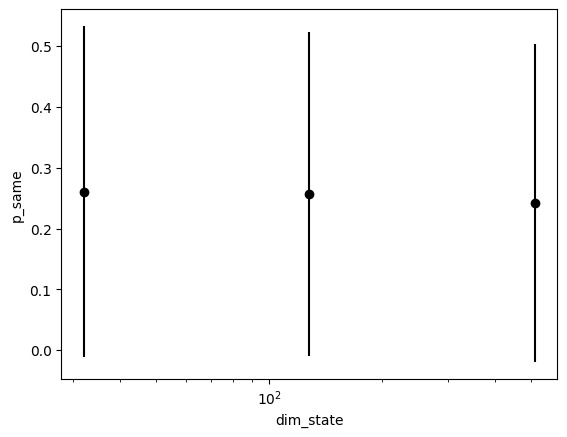

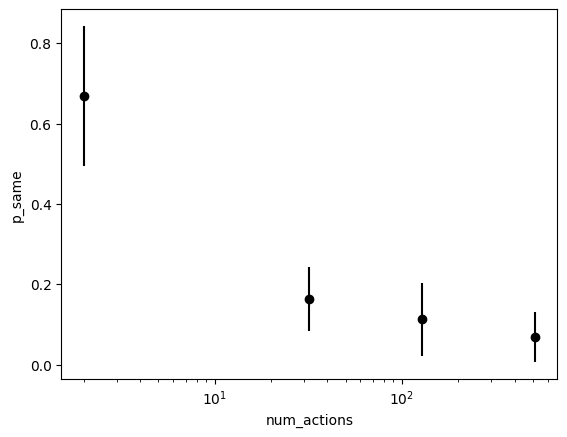

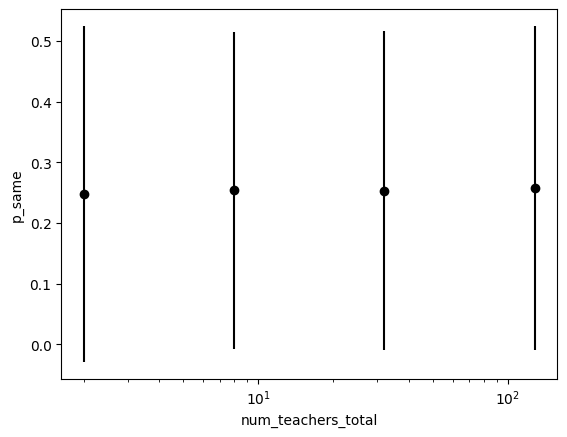

In [100]:
import matplotlib.pyplot as plt
import math

x_axes = ['dim_state', 'num_actions', 'num_teachers_total']

p_same = df.p_same.to_numpy()
num_teachers_total = df.num_teachers_total.to_numpy()


for x_ax in x_axes:
    for k, g in df.groupby(x_ax):
        plt.errorbar(
            x=g[x_ax].iloc[0], 
            y=g.p_same.mean(), 
            yerr=g.p_same.std(), 
            fmt='o',
            color='black')
    plt.xlabel(x_ax)
    plt.xscale('log')
    plt.ylabel('p_same')
    plt.show()



# Output class distribution

In [120]:
grid_search_params = dict(
    dim_state=[32,64,128],
    num_actions=[16,32,64],
    num_teachers_total=[1],
    dim_observation=[64],
    observation_fn_layers=[1],
    observation_fn_dim=[64],
    seed_init=[42**i for i in range(3)],
)

def grid_search_iter():
    gsk = list(grid_search_params.keys())
    for p in itertools.product(*[grid_search_params[k] for k in gsk]):
        d = {k: v for k, v in zip(gsk, p)}
        yield d


grid_search = list(grid_search_iter())
print(f"Grid search has {len(grid_search)} configurations")
df = pd.DataFrame(columns=list(grid_search_params.keys()) + ["p_top", "entropy"])

for p in tqdm(grid_search):
    faculty_cfg = BanditFacultyConfig(**p)
    faculty = BanditFaculty(faculty_cfg)
    # states: (bsz, dim_state)
    # actions: (num_agents, bsz)
    states = faculty.sample_states(TOTAL_BSZ)
    actions = faculty.sample_actions(states, faculty.sample_teachers()).t()

    # Compute histo of actions
    action_hist = torch.histc(actions.float(), bins=faculty_cfg.num_actions, min=0, max=faculty_cfg.num_actions-1)
    action_hist = action_hist / action_hist.sum()
    entropy = - (action_hist * torch.log(action_hist+1e-8)).sum()

    # Compute top action
    top_action = action_hist.argmax().item()
    p_top = action_hist[top_action].item()
    df.loc[len(df)] = {**p, "p_top": p_top, "entropy": entropy.item()}

Grid search has 27 configurations


/tmp/ipykernel_680371/456684128.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for p in tqdm(grid_search):


  0%|          | 0/27 [00:00<?, ?it/s]

In [121]:
df

,dim_state,num_actions,num_teachers_total,dim_observation,observation_fn_layers,observation_fn_dim,seed_init,p_top,entropy
0,32,16,1,64,1,64,1,0.131836,2.549998
1,32,16,1,64,1,64,42,0.122070,2.656908
2,32,16,1,64,1,64,1764,0.167969,2.519876
3,32,32,1,64,1,64,1,0.096680,3.123596
4,32,32,1,64,1,64,42,0.118164,3.182935
5,32,32,1,64,1,64,1764,0.108398,3.051148
6,32,64,1,64,1,64,1,0.072266,3.610582
7,32,64,1,64,1,64,42,0.096680,3.698564
8,32,64,1,64,1,64,1764,0.081055,3.557471
9,64,16,1,64,1,64,1,0.167969,2.599023


In [122]:
actions.shape

torch.Size([1024, 1])